# Predictive Maintenance Feature Analysis & Visualizations

This notebook performs data exploration, statistical hypothesis testing (Welch's T-Test and One-Way ANOVA), outlier analysis, and generates 4 core predictive maintenance visualizations using `pdm_synthetic_features.csv`.

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# Load dataset
DATA_PATH = 'Week6/practical/Statistical-Predictive-Maintenance/data/pdm_synthetic_features.csv'
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (2640, 20)


,timestamp,asset_id,depot,shift,asset_age_months,vibration_g,temperature_c,pressure_psi,acoustic_db,motor_current_a,error_events,constant_sensor,time_to_failure_hours,health_status,fault_type,failure_within_7_days,vibration_roll_mean_6,vibration_rms_6,vibration_peak_to_peak_6,temp_roll_mean_6
0,01/01/2026 00:00,PUMP-001,North,Day,15,1.3056,64.4815,123.4455,69.9614,34.8057,0,1,641.33,Healthy,Normal,0,1.305600,1.305600,0.0000,64.481500
1,01/01/2026 06:00,PUMP-001,North,Night,15,1.8329,65.2009,121.4905,70.8481,34.6576,1,1,658.44,Healthy,Normal,0,1.569250,1.591244,0.5273,64.841200
2,01/01/2026 12:00,PUMP-001,North,Day,15,1.7601,63.9732,123.0420,69.1901,36.7452,0,1,638.09,Healthy,Normal,0,1.632867,1.649451,0.5273,64.551867
3,01/01/2026 18:00,PUMP-001,North,Night,15,2.0155,63.6278,122.7399,68.1283,36.8624,0,1,644.73,Healthy,Normal,0,1.728525,1.748164,0.7099,64.320850
4,02/01/2026 00:00,PUMP-001,North,Day,15,1.3916,65.4224,127.2597,71.2493,35.0683,0,1,633.20,Healthy,Normal,0,1.661140,1.682906,0.7099,64.541160


In [4]:
# Descriptive statistics and cleaning checks
numeric = df.select_dtypes(include='number')
summary = numeric.describe(percentiles=[.05, .25, .5, .75, .95]).T
constant_columns = [c for c in df.columns if df[c].nunique(dropna=False) == 1]
missing_counts = df.isna().sum()

print("--- Constant Columns ---")
print(constant_columns)
print("\n--- Missing Values Count ---")
print(missing_counts[missing_counts > 0])
print("\n--- Summary Statistics ---")
summary

--- Constant Columns ---
['constant_sensor']

--- Missing Values Count ---
pressure_psi    9
acoustic_db     9
dtype: int64

--- Summary Statistics ---


,count,mean,std,min,5%,25%,50%,75%,95%,max
asset_age_months,2640.0,52.541667,29.065758,8.000000,9.000000,28.000000,47.000000,83.500000,94.000000,95.000000
vibration_g,2640.0,2.208835,0.868509,0.676800,1.251980,1.676925,1.955950,2.415475,4.153660,10.480780
temperature_c,2640.0,64.845955,6.913448,51.381200,55.906790,60.258075,63.869700,67.580875,78.530100,122.982900
pressure_psi,2631.0,117.076871,8.271105,88.152700,102.324700,111.757400,117.627900,123.202350,129.528050,138.198500
acoustic_db,2631.0,71.286330,3.366274,61.608700,66.621650,68.972450,70.780100,73.121700,77.698050,84.311100
motor_current_a,2640.0,37.092423,2.488640,31.227800,33.876990,35.455875,36.570400,38.163825,42.404885,47.258600
error_events,2640.0,0.531439,0.875196,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,6.000000
constant_sensor,2640.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
time_to_failure_hours,2640.0,332.972455,191.411161,0.000000,36.274000,165.645000,334.105000,494.965000,630.931000,742.800000
failure_within_7_days,2640.0,0.253409,0.435046,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000


In [5]:
# 3-Standard-Deviation Outlier Flags
z = (numeric - numeric.mean()) / numeric.std(ddof=0)
outlier_counts = (z.abs() > 3).sum().sort_values(ascending=False)

print("--- Outlier Counts (|Z| > 3) ---")
print(outlier_counts)

--- Outlier Counts (|Z| > 3) ---
error_events                37
vibration_peak_to_peak_6    34
vibration_roll_mean_6       25
vibration_rms_6             22
motor_current_a             21
acoustic_db                 16
temp_roll_mean_6            12
vibration_g                 12
temperature_c                9
pressure_psi                 7
asset_age_months             0
failure_within_7_days        0
constant_sensor              0
time_to_failure_hours        0
dtype: int64


In [6]:
# 1. Independent T-test: Vibration by Shift (Day vs Night)
day_vib = df.loc[df['shift'] == 'Day', 'vibration_g'].dropna()
night_vib = df.loc[df['shift'] == 'Night', 'vibration_g'].dropna()
t_stat, p_val_t = stats.ttest_ind(day_vib, night_vib, equal_var=False)

print("=== Independent T-Test (Vibration: Day vs Night) ===")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val_t:.6f}")
print(f"Day Mean: {day_vib.mean():.4f}, Night Mean: {night_vib.mean():.4f}")
print("Conclusion:", "Reject H0 (Statistically significant difference)" if p_val_t < 0.05 else "Fail to reject H0")

print("\n" + "="*50 + "\n")

# 2. One-Way ANOVA: Pressure across Depots
depot_samples = [group['pressure_psi'].dropna() for _, group in df.groupby('depot')]
f_stat, p_val_anova = stats.f_oneway(*depot_samples)

print("=== One-Way ANOVA (Pressure across Depots) ===")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val_anova:.6f}")
print("Conclusion:", "Reject H0 (Statistically significant difference across depots)" if p_val_anova < 0.05 else "Fail to reject H0")

=== Independent T-Test (Vibration: Day vs Night) ===
T-statistic: -2.7430, p-value: 0.006131
Day Mean: 2.1675, Night Mean: 2.2605
Conclusion: Reject H0 (Statistically significant difference)


=== One-Way ANOVA (Pressure across Depots) ===
F-statistic: 42.2991, p-value: 0.000000
Conclusion: Reject H0 (Statistically significant difference across depots)


## Visualizations

Below are the 4 core visualizations examining operational parameters, feature correlations, and equipment health status distributions.

/tmp/ipykernel_857416/2378830851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="shift", y="vibration_g", data=df, palette="Set2")


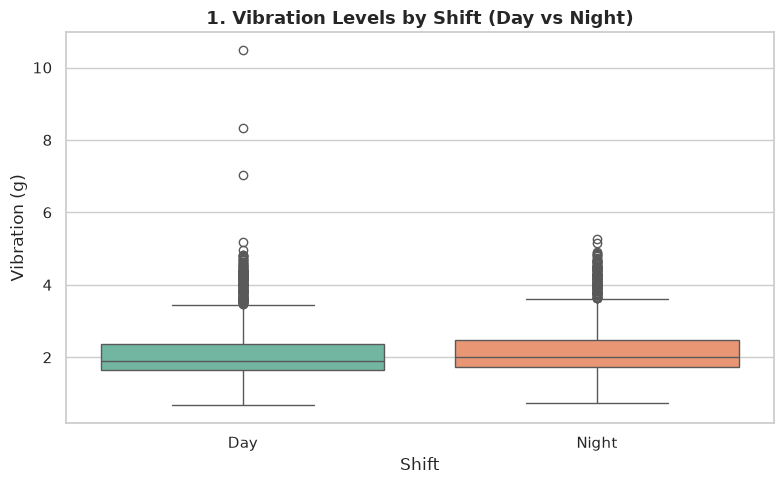

In [7]:
# Visualization 1: Vibration Levels by Shift
plt.figure(figsize=(8, 5))
sns.boxplot(x="shift", y="vibration_g", data=df, palette="Set2")
plt.title("1. Vibration Levels by Shift (Day vs Night)", fontsize=13, fontweight='bold')
plt.xlabel("Shift")
plt.ylabel("Vibration (g)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_857416/2311455520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


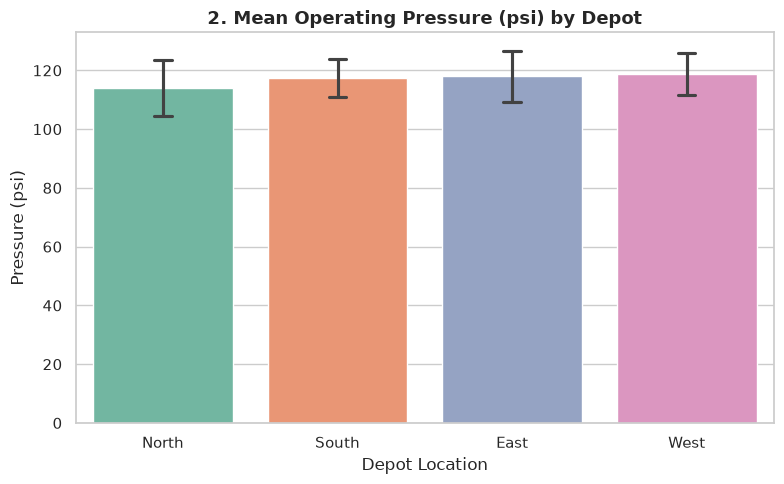

In [8]:
# Visualization 2: Mean Pressure by Depot
plt.figure(figsize=(8, 5))
sns.barplot(
    x="depot", 
    y="pressure_psi", 
    data=df, 
    palette="Set2",
    errorbar="sd",
    capsize=0.1
)
plt.title("2. Mean Operating Pressure (psi) by Depot", fontsize=13, fontweight='bold')
plt.xlabel("Depot Location")
plt.ylabel("Pressure (psi)")
plt.tight_layout()
plt.show()

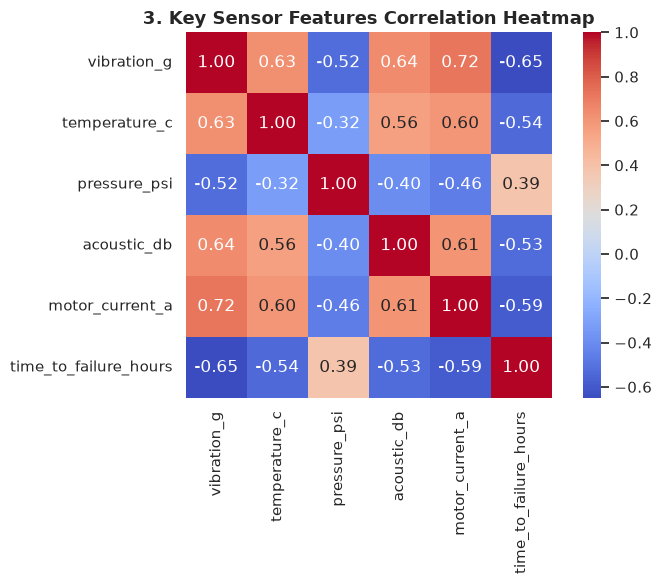

In [9]:
# Visualization 3: Feature Correlation Matrix
plt.figure(figsize=(8, 6))
core_metrics = ['vibration_g', 'temperature_c', 'pressure_psi', 'acoustic_db', 'motor_current_a', 'time_to_failure_hours']
sns.heatmap(df[core_metrics].corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("3. Key Sensor Features Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

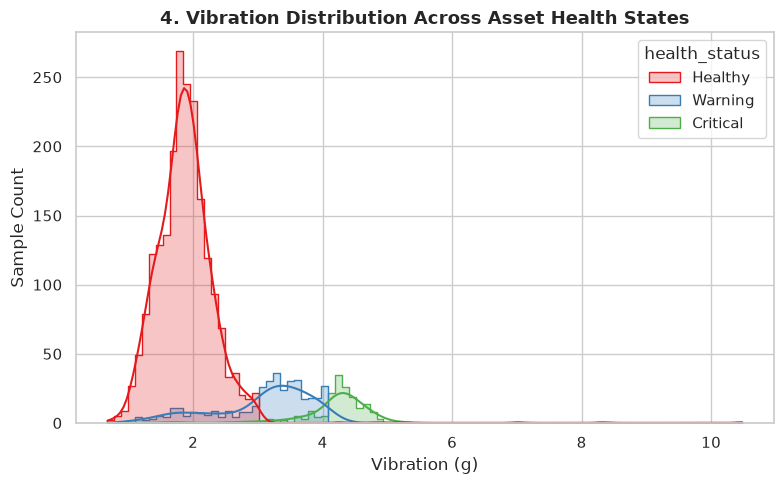

In [10]:
# Visualization 4: Vibration Distribution by Health Status
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df, 
    x="vibration_g", 
    hue="health_status", 
    kde=True, 
    element="step", 
    palette="Set1"
)
plt.title("4. Vibration Distribution Across Asset Health States", fontsize=13, fontweight='bold')
plt.xlabel("Vibration (g)")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.show()

/tmp/ipykernel_857416/3683088030.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 0], x="shift", y="vibration_g", data=df, palette="Set2")
/tmp/ipykernel_857416/3683088030.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 1], x="depot", y="pressure_psi", data=df, palette="Set2", errorbar="sd", capsize=0.1)


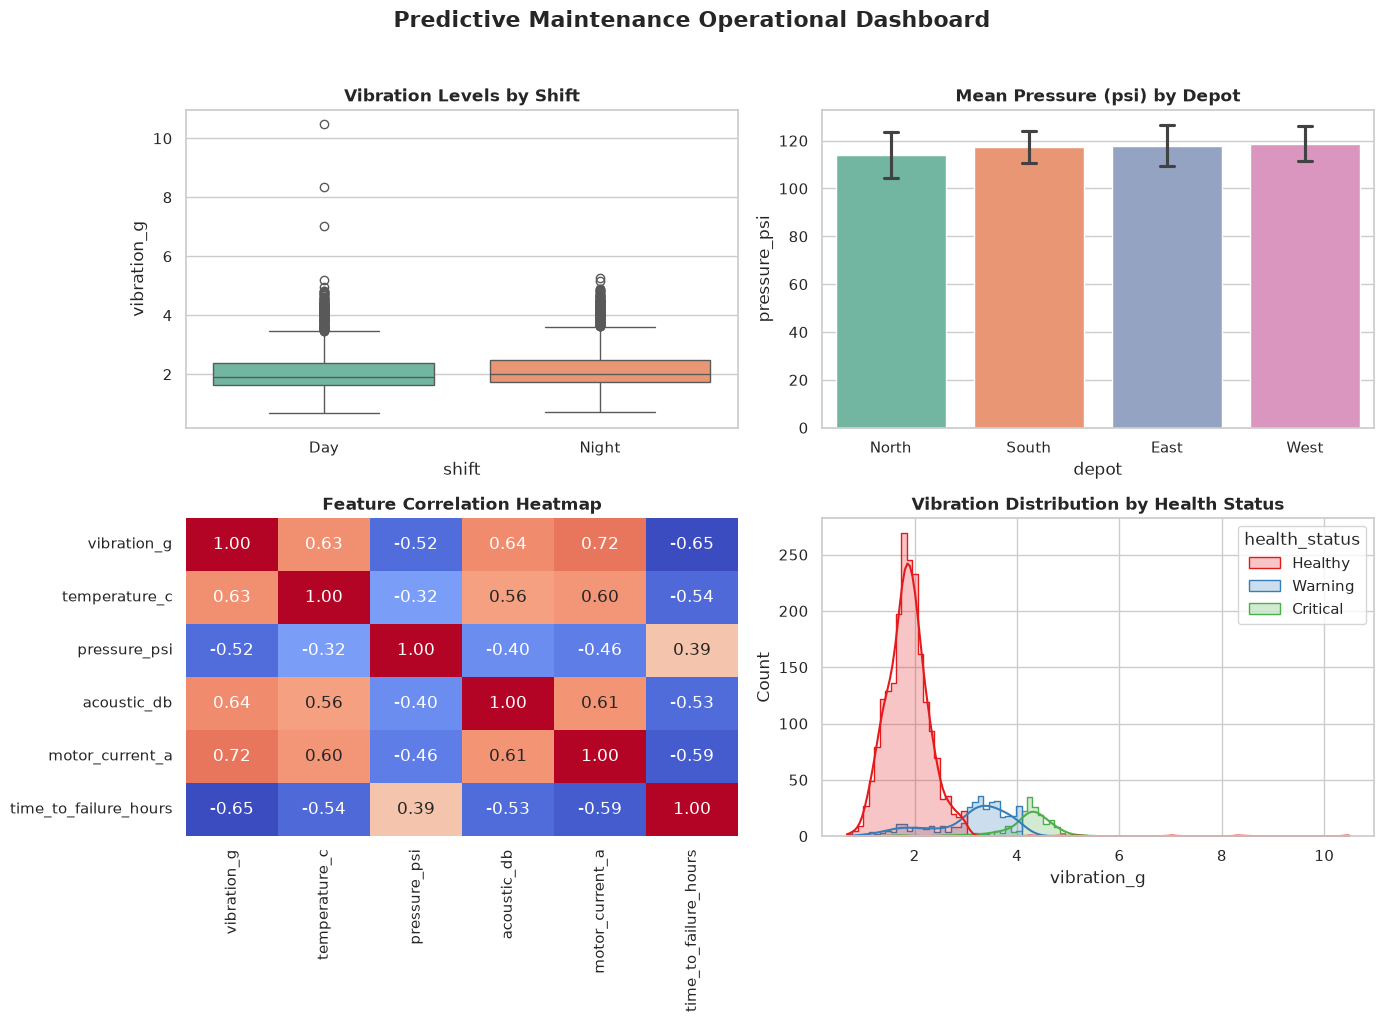

In [11]:
# Consolidated 2x2 Visual Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Vibration by Shift
sns.boxplot(ax=axes[0, 0], x="shift", y="vibration_g", data=df, palette="Set2")
axes[0, 0].set_title("Vibration Levels by Shift", fontweight='bold')

# 2. Pressure by Depot
sns.barplot(ax=axes[0, 1], x="depot", y="pressure_psi", data=df, palette="Set2", errorbar="sd", capsize=0.1)
axes[0, 1].set_title("Mean Pressure (psi) by Depot", fontweight='bold')

# 3. Correlation Heatmap
core_metrics = ['vibration_g', 'temperature_c', 'pressure_psi', 'acoustic_db', 'motor_current_a', 'time_to_failure_hours']
sns.heatmap(ax=axes[1, 0], data=df[core_metrics].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
axes[1, 0].set_title("Feature Correlation Heatmap", fontweight='bold')

# 4. Health Status Distribution
sns.histplot(ax=axes[1, 1], data=df, x="vibration_g", hue="health_status", kde=True, element="step", palette="Set1")
axes[1, 1].set_title("Vibration Distribution by Health Status", fontweight='bold')

plt.suptitle("Predictive Maintenance Operational Dashboard", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("pdm_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()